## Example 0 - Climate coin
### Motivating example

In [2]:
### Imports
import re
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as t_test
from scipy.stats import binom, norm
from scipy.integrate import quad
from pathlib import Path

### Plots
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MaxNLocator

### Color list of dark organges in named colors by number
dark_oranges = sns.color_palette("Oranges", n_colors=9)[4:]
dark_purples = sns.color_palette("Purples", n_colors=9)[4:]
dark_greens = sns.color_palette("Greens", n_colors=9)[4:]

In [ ]:
### Interpretation of the Bayes factor in terms of simple (nested) or complex model
def interpret_bayes_factor(bf):
    if bf < 1:
        interpretation = "Evidence favors the simpler model"
    elif 1 <= bf < 3:
        interpretation = "Anecdotal evidence for the complex model"
    elif 3 <= bf < 10:
        interpretation = "Substantial evidence for the complex model"
    elif 10 <= bf < 30:
        interpretation = "Strong evidence for the complex model"
    elif 30 <= bf < 100:
        interpretation = "Very strong evidence for the complex model"
    else:
        interpretation = "Decisive evidence for the complex model"
    print(f"Bayes Factor: {bf:.3g} - {interpretation}")

In [3]:
# -----------------------
# Settings for the example
# -----------------------
n = 50
x_obs = 32
x_vals = np.arange(0, n+1)
theta_grid = np.linspace(0, 1, 1000)

# -----------------------
# Prior distributions
# -----------------------

# Uniform prior on [0.5, 0.6]
def uniform_prior(theta):
    return np.where((theta >= 0.5) & (theta <= 0.6), 1/0.1, 0)

def uniform_full_prior(theta):
    return np.where((theta >= 0) & (theta <= 1), 1, 0)

# Gaussian prior N(0.6, 0.1^2), truncated to [0,1]
def gaussian_prior(theta):
    prior = norm.pdf(theta, 0.6, 0.1)
    prior[(theta < 0) | (theta > 1)] = 0
    return prior

# -----------------------
# Prior predictive distributions
# -----------------------

# Prior predictive for uniform prior
def prior_predictive_uniform(x):
    integrand = lambda t: binom.pmf(x, n, t) * (1/0.1 if 0.5 <= t <= 0.6 else 0)
    return quad(integrand, 0.5, 0.6)[0]

# Prior predictive for uniform prior
def prior_predictive_full_uniform(x):
    integrand = lambda t: binom.pmf(x, n, t) * (1 if 0 <= t <= 1 else 0)
    return quad(integrand, 0, 1)[0]

# Prior predictive for Gaussian prior
def prior_predictive_gaussian(x):
    integrand = lambda t: binom.pmf(x, n, t) * norm.pdf(t, 0.6, 0.1)
    return quad(integrand, 0, 1)[0]

# Compute predictive distributions
pp_full_uniform = np.array([prior_predictive_full_uniform(x) for x in x_vals])
pp_uniform = np.array([prior_predictive_uniform(x) for x in x_vals])
pp_gaussian = np.array([prior_predictive_gaussian(x) for x in x_vals])

# Normalize Gaussian predictive (because truncated)
pp_gaussian /= pp_gaussian.sum()


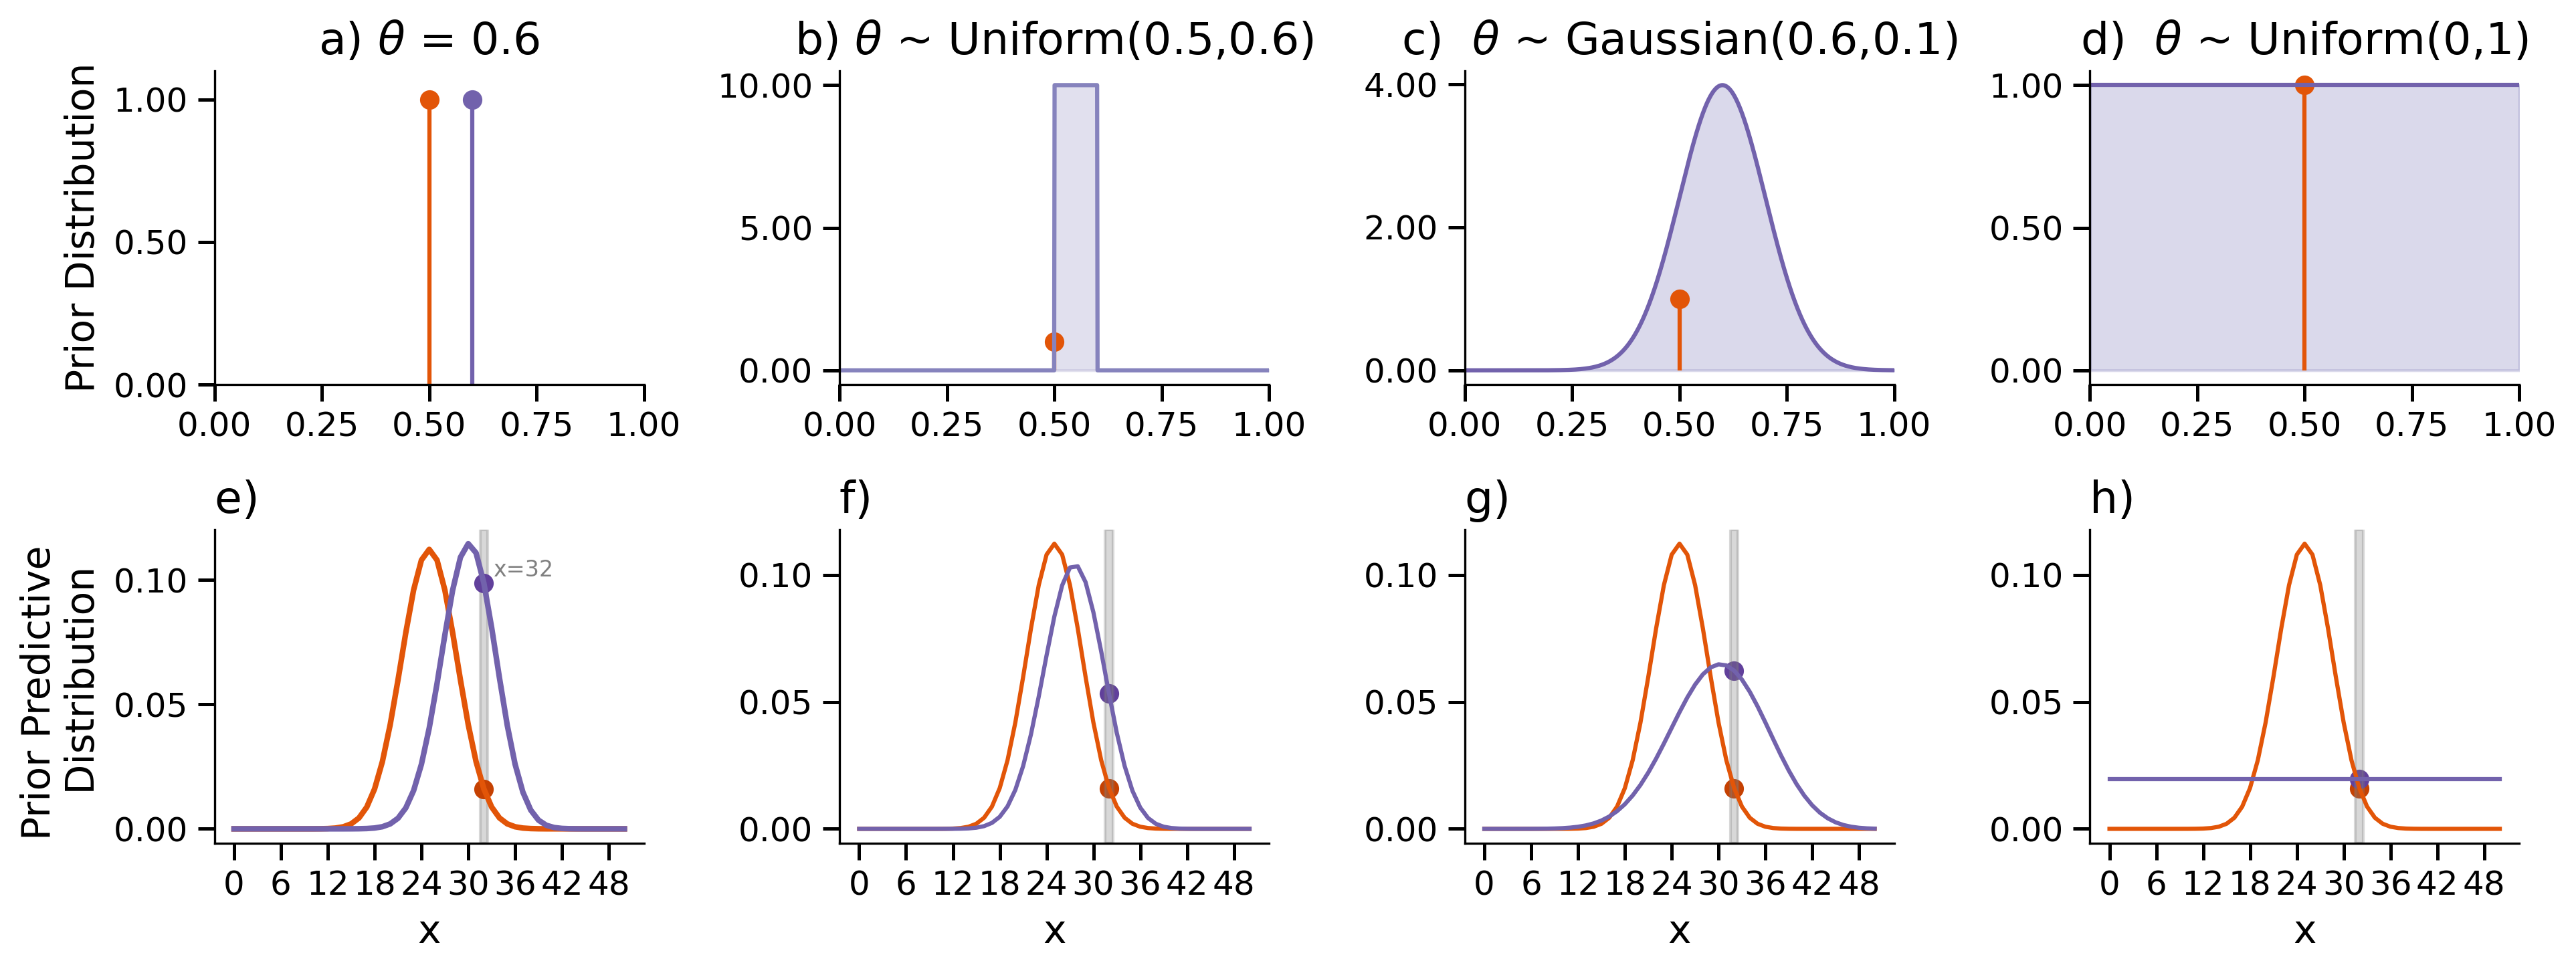

In [5]:

plt.rcParams.update({
    "font.size": 12,          # base font
    "axes.titlesize": 16,     # subplot titles
    "axes.labelsize": 14,     # axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})


# -----------------------
# Plot
# -----------------------
fig, axes = plt.subplots(2, 4, figsize=(13, 5), dpi=300)

# ---- Subplot A ----
ax = axes[0, 0]
markerline, stemlines, baseline = ax.stem([0.5], [1], linefmt='C0-', markerfmt='C0o', basefmt=" ")
markerline_2, stemlines_2, baseline_2 = ax.stem([0.6], [1], linefmt='C1-', markerfmt='C1o', basefmt=" ")
plt.setp(markerline, color=dark_oranges[2])
plt.setp(stemlines, color=dark_oranges[2])
plt.setp(baseline, color=dark_oranges[2])
plt.setp(markerline_2, color=dark_purples[2])
plt.setp(stemlines_2, color=dark_purples[2])
plt.setp(baseline_2, color=dark_purples[2])
ax.set_title(r'a) $\theta$ = 0.6')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Prior Distribution")

# ---- Subplot B ----
ax = axes[0, 1]
markerline, stemlines, baseline = ax.stem([0.5], [1], linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.setp(markerline, color=dark_oranges[2])
plt.setp(stemlines, color=dark_oranges[2])
plt.setp(baseline, color=dark_oranges[2])
ax.plot(theta_grid, uniform_prior(theta_grid), color=dark_purples[1])
### Add light shading below the uniform prior
ax.fill_between(theta_grid, uniform_prior(theta_grid), color=dark_purples[0], alpha=0.3)
ax.set_title(r'b) $\theta$ ~ Uniform(0.5,0.6)')
ax.set_xlim(0, 1)

# ---- Subplot C ----
ax = axes[0, 2]
markerline, stemlines, baseline = ax.stem([0.5], [1], linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.setp(markerline, color=dark_oranges[2])
plt.setp(stemlines, color=dark_oranges[2])
plt.setp(baseline, color=dark_oranges[2])
ax.plot(theta_grid, gaussian_prior(theta_grid), color=dark_purples[2])
### Add light shading below the gaussian prior
ax.fill_between(theta_grid, gaussian_prior(theta_grid), color=dark_purples[1], alpha=0.3)
ax.set_title(r'c)  $\theta$ ~ Gaussian(0.6,0.1)')
ax.set_xlim(0, 1)

# ---- Subplot C ----
ax = axes[0, 3]
markerline, stemlines, baseline = ax.stem([0.5], [1], linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.setp(markerline, color=dark_oranges[2])
plt.setp(stemlines, color=dark_oranges[2])
plt.setp(baseline, color=dark_oranges[2])
ax.plot(theta_grid, uniform_full_prior(theta_grid), color=dark_purples[2])
### Add light shading below the gaussian prior
ax.fill_between(theta_grid, uniform_full_prior(theta_grid), color=dark_purples[1], alpha=0.3)
ax.set_title(r'd)  $\theta$ ~ Uniform(0,1)')
ax.set_xlim(0, 1)

# ---- Subplot D ----
ax = axes[1, 0]
ax.plot(x_vals, binom.pmf(x_vals, n, 0.5), color=dark_oranges[2],linewidth=2)
ax.plot(x_vals, binom.pmf(x_vals, n, 0.6), color=dark_purples[2],linewidth=2)
ax.axvspan(x_obs-0.5, x_obs+0.5, color='grey', alpha=0.3)
ax.text(x_obs+5, ax.get_ylim()[1]*0.9, f'x={x_obs}', ha='center', va='top', fontsize=8, color='grey')
ax.scatter(x_obs, binom.pmf(x_obs, n, 0.5), color=dark_oranges[3], marker='o')
ax.scatter(x_obs, binom.pmf(x_obs, n, 0.6), color=dark_purples[3], marker='o')
ax.set_title('e) ',loc='left')
ax.set_xlabel("x")
ax.set_ylabel("Prior Predictive \n Distribution")

# ---- Subplot E ----
ax = axes[1, 1]
ax.plot(x_vals, binom.pmf(x_vals, n, 0.5), color=dark_oranges[2])
ax.plot(x_vals, pp_uniform, color=dark_purples[2])
ax.scatter(x_obs, binom.pmf(x_obs, n, 0.5), color=dark_oranges[3], marker='o')
ax.scatter(x_obs, prior_predictive_uniform(x_obs), color=dark_purples[3], marker='o')
ax.axvspan(x_obs-0.5, x_obs+0.5, color='grey', alpha=0.3)
ax.set_title("f) ",loc='left')
ax.set_xlabel("x")


# ---- Subplot F ----
ax = axes[1, 2]
ax.plot(x_vals, binom.pmf(x_vals, n, 0.5), color=dark_oranges[2])
ax.plot(x_vals, pp_gaussian, color=dark_purples[2])
ax.scatter(x_obs, binom.pmf(x_obs, n, 0.5), color=dark_oranges[3], marker='o')
ax.scatter(x_obs, prior_predictive_gaussian(x_obs), color=dark_purples[3], marker='o')
ax.axvspan(x_obs-0.5, x_obs+0.5, color='grey', alpha=0.3)
ax.set_title("g) ",loc='left')
ax.set_xlabel("x")

# ---- Subplot F ----
ax = axes[1, 3]
ax.plot(x_vals, binom.pmf(x_vals, n, 0.5), color=dark_oranges[2])
ax.plot(x_vals, pp_full_uniform, color=dark_purples[2])
ax.scatter(x_obs, binom.pmf(x_obs, n, 0.5), color=dark_oranges[3], marker='o')
ax.scatter(x_obs, prior_predictive_full_uniform(x_obs), color=dark_purples[3], marker='o')
ax.axvspan(x_obs-0.5, x_obs+0.5, color='grey', alpha=0.3)
ax.set_title("h) ",loc='left')
ax.set_xlabel("x")


# for ax in axes.flat:
#     ax.xaxis.set_major_locator(MaxNLocator(nbins=8))  # more x ticks
#     ax.yaxis.set_major_locator(MaxNLocator(nbins=6))  # more y ticks

for ax in axes.flat:
    ax.tick_params(axis='both', which='major', length=6, width=1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# Top row → decimals
for ax in axes[0, :]:
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Bottom row → integers
for ax in axes[1, :]:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
plt.tight_layout()
plt.show()

In [6]:
### Frequentist estimate of theta from data
theta_hat = x_obs / n
print(f"Frequentist estimate of theta: {theta_hat:.3f}")
### 95 confidence interval for theta
ci_lower = binom.ppf(0.025, n, theta_hat) / n
ci_upper = binom.ppf(0.975, n, theta_hat) / n
print(f"95% confidence interval for theta: [{ci_lower:.3f}, {ci_upper:.3f}]")

Frequentist estimate of theta: 0.640
95% confidence interval for theta: [0.500, 0.760]


In [7]:
BF_1 = binom.pmf(x_obs, n, 0.6) / binom.pmf(x_obs, n, 0.5)

BF_2 = prior_predictive_uniform(x_obs) / binom.pmf(x_obs, n, 0.5)

BF_3 = prior_predictive_gaussian(x_obs) / binom.pmf(x_obs, n, 0.5)

BF_4 = prior_predictive_full_uniform(x_obs) / binom.pmf(x_obs, n, 0.5)

print("Bayes Factor (Point 0.6 vs Point 0.5):", BF_1)
print("Bayes Factor (Uniform[0.5,0.6] vs Point 0.5):", BF_2)
print("Bayes Factor (Gaussian(0.6,0.1) vs Point 0.5):", BF_3)
print("Bayes Factor (Uniform[0,1] vs Point 0.5):", BF_4)


Bayes Factor (Point 0.6 vs Point 0.5): 6.157715779441302
Bayes Factor (Uniform[0.5,0.6] vs Point 0.5): 3.322211678303773
Bayes Factor (Gaussian(0.6,0.1) vs Point 0.5): 3.8851368684054903
Bayes Factor (Uniform[0,1] vs Point 0.5): 1.2228339901713383


### Cumulative evidence

In [8]:
# -----------------------
# Open data and compute global mean surface temperature (GMST) anomalies
# -----------------------

# Start search from the user's home directory
home_dir = Path.home()

# Open data file from under BF_codes/data
data_file = None
for path in home_dir.rglob("BF_codes/data/DCENT_GMST_statistics.txt"):
    data_file = path
    break  

# 1) Find the header line ("Year,GMST (°C),...")
with open(path, "r", encoding="utf-8") as f:
    lines = f.readlines()

start = next(i for i, line in enumerate(lines) if line.strip().startswith("Year,"))

# 2) Read CSV from that header line onward; allow commas with spaces
df = pd.read_csv(
    path,
    skiprows=start,               # start at the header line
    engine="python",
    sep=r"\s*,\s*",               # split on commas, ignoring surrounding spaces
    comment=None
)

# 3) Clean column names to something easy to use
rename_map = {
    "Year": "year",
    "GMST (°C)": "gmst",
    "1 s.d. (°C)": "gmst_sd",
    "GMST non infilled (°C)": "gmst_noninf",
    "1 s.d. (°C; non  infilled)": "gmst_noninf_sd",
}
# in case of double spaces etc., normalize header keys first
df.columns = [re.sub(r"\s+", " ", c).strip() for c in df.columns]
rename_map_norm = {re.sub(r"\s+", " ", k).strip(): v for k, v in rename_map.items()}
df = df.rename(columns=rename_map_norm)

# 4) Ensure numeric dtypes
for c in ["year", "gmst", "gmst_sd", "gmst_noninf", "gmst_noninf_sd"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 5) Convert to xarray (optional)
ds = xr.Dataset(
    {
        "GMST": (["year"], df["gmst"].values),
        "GMST_sd": (["year"], df["gmst_sd"].values),
        "GMST_non_infilled": (["year"], df["gmst_noninf"].values),
        "GMST_non_infilled_sd": (["year"], df["gmst_noninf_sd"].values),
    },
    coords={"year": df["year"].values.astype(int)},
)
ds_full = ds.copy()
ds = ds - ds.sel(year=slice('1950','1981')).mean(dim='year')

# --- Shape data ---
t = ds.sel(year=slice('1950','2025')).year
y = ds['GMST'].sel(year=slice('1950','2025')).values
n = len(y)

In [9]:
for i in range(len(y[4:])):
    print(np.sum(y[4:i]>0),i)

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
1 9
2 10
2 11
3 12
4 13
5 14
5 15
5 16
5 17
5 18
5 19
6 20
7 21
7 22
8 23
9 24
9 25
9 26
9 27
10 28
11 29
12 30
13 31
14 32
15 33
16 34
17 35
18 36
19 37
20 38
21 39
22 40
23 41
24 42
25 43
26 44
27 45
28 46
29 47
30 48
31 49
32 50
33 51
34 52
35 53
36 54
37 55
38 56
39 57
40 58
41 59
42 60
43 61
44 62
45 63
46 64
47 65
48 66
49 67
50 68
51 69
52 70


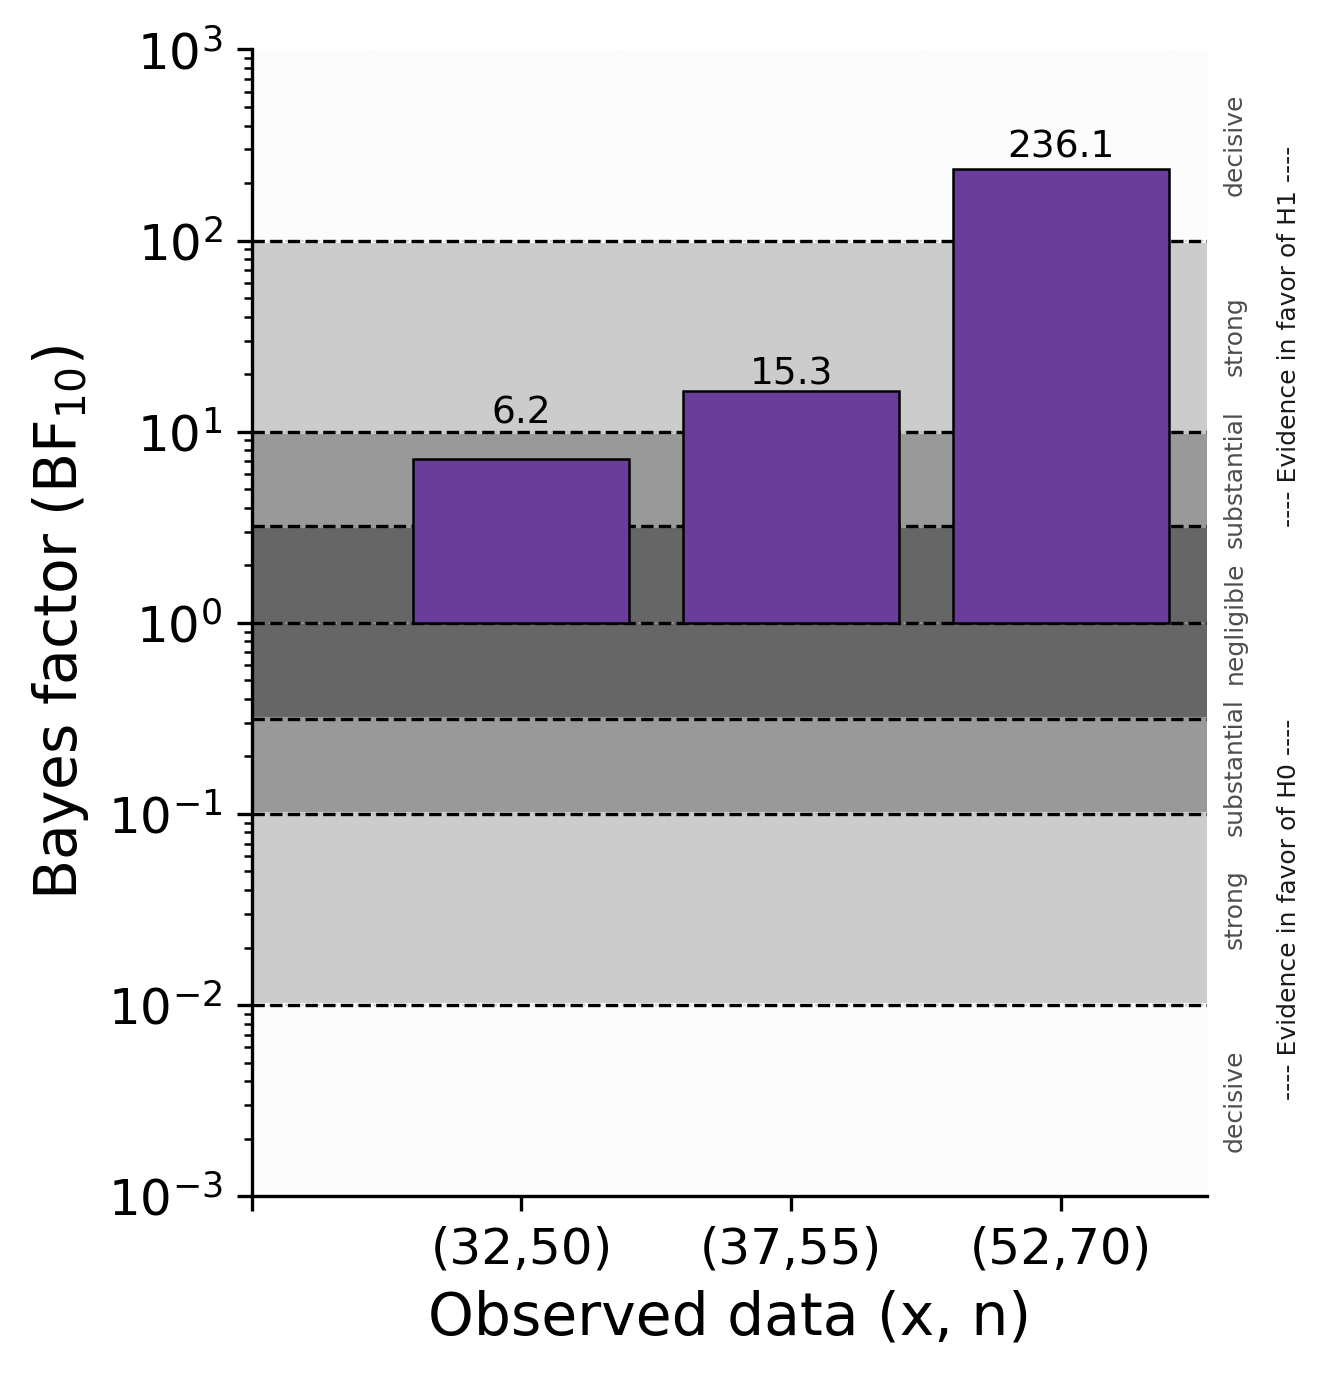

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# ======================
# Hypotheses
# ======================
p0 = 0.5
p1 = 0.6

# Three scenarios
cases = [
    (32, 50),  # initial
    (37, 55),  # +5 years
    (52, 70)   # +20 years → decisive
]

labels = ["", "(32,50)", "(37,55)", "(52,70)"]  # empty first tick for alignment

# ======================
# Compute Bayes factors
# ======================
BFs = [np.nan]  # dummy for first empty tick
for x, n in cases:
    L1 = binom.pmf(x, n, p1)
    L0 = binom.pmf(x, n, p0)
    BFs.append(L1 / L0)
BFs = np.array(BFs)
xpos = np.arange(len(labels))

# ======================
# Plot
# ======================
fig, ax = plt.subplots(figsize=(5.5, 5), dpi=300)

# Shaded evidence regions
ax.axhspan(1, 3.2, color="0.4", zorder=0)   # negligible
ax.axhspan(3.2, 10, color="0.6", zorder=0)  # substantial
ax.axhspan(10, 100, color="0.8", zorder=0)  # strong
ax.axhspan(100, 1000, color="0.99", zorder=0)  # decisive

ax.axhspan(1/3.2,1, color="0.4", zorder=0)   # negligible
ax.axhspan(1/10,1/3.2, color="0.6", zorder=0)  # substantial
ax.axhspan(1/100,1/10, color="0.8", zorder=0)  # strong
ax.axhspan(1/100,1/1000, color="0.99", zorder=0)  # decisive

from matplotlib.ticker import LogLocator, LogFormatterMathtext

# Bars (start from 1)
ax.bar(
    xpos[1:], 
    BFs[1:], 
    bottom=1,
    color="#6A3D9A", 
    edgecolor='black', 
    linewidth=0.6, 
    zorder=3
)

# Threshold lines (above AND below 1)
thresholds = [1, 3.2, 10, 100]
for t in thresholds:
    ax.axhline(t, color='black', linestyle='--', linewidth=0.8, zorder=2)
    if t != 1:
        ax.axhline(1/t, color='black', linestyle='--', linewidth=0.8, zorder=2)

# Log scale + limits
ax.set_yscale("log")
ax.set_ylim(1/1000, 1000)

# Proper 10^x ticks
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))

# Optional: minor ticks for readability
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))
ax.yaxis.set_minor_formatter(lambda *args: "")

# Labels
ax.set_ylabel("Bayes factor (BF$_{10}$)")
ax.set_xlabel("Observed data (x, n)")

# ======================
# Vertical regime labels on the right
# ======================
x_text = xpos[-1] + 0.6  # just outside the last bar
regimes = [
    (1/3.2, 3.2, "negligible"),
    (3.2, 10, "substantial"),
    (10, 100, "strong"),
    (100, 1000, "decisive")
]
for y0, y1, label in regimes:
    ax.text(
        x_text, 
        10**((np.log10(y0)+np.log10(y1))/2),  # center in log-space
        label, rotation=90, va='center', ha='left', fontsize=6, color='0.3'
    )

regimes = [
    (1/10, 1/3.2, "substantial"),
    (1/100, 1/10, "strong"),
    (1/1000, 1/100, "decisive")
]
for y0, y1, label in regimes:
    ax.text(
        x_text, 
        10**((np.log10(y0)+np.log10(y1))/2),  # center in log-space
        label, rotation=90, va='center', ha='left', fontsize=6, color='0.3'
    )

x_text = xpos[-1] + 0.8  # just outside the last bar
evidence_label = [
    (1/1000, 1, "---- Evidence in favor of H0 ----"),
    (1,1000, "---- Evidence in favor of H1 ----"),
]

for y0, y1, label in evidence_label:
    ax.text(
        x_text, 
        10**((np.log10(y0)+np.log10(y1))/2),  # center in log-space
        label, rotation=90, va='center', ha='left', fontsize=6, color='0.1'
    )

# Annotate BF values above bars
for i in range(2, len(BFs)):
    ax.text(xpos[i], BFs[i]*1.15, f"{BFs[i]:.1f}", ha='center', fontsize=9)

ax.text(xpos[1], BFs[1]*1.8, f"{BFs[1]:.1f}", ha='center', fontsize=9)

ax.set_xticks(xpos) 
ax.set_xticklabels(labels)

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

# Layout adjustments
plt.tight_layout(rect=[0.1, 0.05, 0.95, 1])
plt.show()